In [2]:
from IPython.display import Image, HTML, display
image_path = "Logos.jpeg"

img_html = Image(url=image_path, width=800)._repr_html_()

centered_image_html = f"<div style='text-align:center;'>{img_html}</div>"

display(HTML(centered_image_html))

import warnings
warnings.filterwarnings('ignore')

<div style="text-align:center"; font-size: 32px;>
    
# Geospatial data analysis

</div>

**Author:** Naziru Halilu


<span style="font-size:120%">
This class aims to introduce students to the manipulation of raster data using programming code.
The following data will be used in the following activity:
    
- The previous filtered agricultural plots (class 1)
- Digital Elevation Model https://centrodedescargas.cnig.es/CentroDescargas/buscar-mapa)
- Orthophotos (https://idena.navarra.es/ogc/wms)

In this class, we will load a 2 m digital elevation model (DEM) and process it to create a slope map with a lower spatial resolution (4 m). We will then use the agricultural plots from the previous class to calculate the mean slope percentage for each. Finally, we will reclassify the slope map into four different ranges, following FAO guidelines, and visualize the results with an orthophoto background.

This activity seeks to enable students to:

- Load and visualise raster information.
- Change raster resolution.
- Calculate raster statistics and reclassify raster data.
- Use web services.
- Export the results obtained.
</span>

## Import libraries

In [1]:
# Manipulating directories and paths
import os #More information https://docs.python.org/3/library/os.html
import glob

# Data manipulation 
import numpy as np
import pandas as pd
from shapely import wkt # To convert geometries to a compatible format

# Spatial data manipulation
import geopandas as gpd #More information https://geopandas.org/en/stable/docs.html

# Raster manipulation
import rasterio # More information https://rasterio.readthedocs.io/en/stable/
from rasterio.enums import Resampling # To change the raster resolution
from rasterio.mask import mask # To clip the raster with a mask considering the vector data
from rasterio.merge import merge # To create a mosaic
from rasterio.windows import from_bounds # To clip the raster by vector extent
from rasterio.warp import transform_bounds
from osgeo import gdal # Slope calculation # More information https://gdal.org/en/stable/index.html

# Raster statistics
from rasterstats import zonal_stats # More information https://pypi.org/project/rasterstats/

# Graphics design
import matplotlib.pyplot as plt # More information https://matplotlib.org/
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from rasterio.plot import show 
from shapely.geometry import mapping
from owslib.wms import WebMapService
import folium


In [3]:
# pip install rasterstats

In [4]:
# pip install owslib

## Load raster data

<span style="font-size:120%">

Load the DEM sheets for our municipality and generate an aggregation of them into a single mosaic. To do this, since these are raster layers, we will use the rasterio library.</br>
The steps for searching and downloading the DEMs used can be found in the class guidelines.

</span>

In [5]:
# Know which is our directory path
os.getcwd()

'C:\\Users\\alumno\\Downloads\\Topic_2'

In [6]:
# Defines the path to the folder where the rasters are located
data_dir = 'Data/DEM/'

# Use the glob library to find all .tif files in the folder
search_criteria = os.path.join(data_dir, '*.tif')
raster_files = glob.glob(search_criteria)
raster_files

['Data/DEM\\MDT02-ETRS89-HU30-0172-4-COB2.tif',
 'Data/DEM\\MDT02-ETRS89-HU30-0173-3-COB2.tif',
 'Data/DEM\\MDT02-ETRS89-HU30-0205-2-COB2.tif',
 'Data/DEM\\MDT02-ETRS89-HU30-0206-1-COB2.tif']

In [7]:
# Open just one raster
src = rasterio.open(raster_files[0], BIGTIFF='YES')
print(src)

<open DatasetReader name='Data/DEM\MDT02-ETRS89-HU30-0172-4-COB2.tif' mode='r'>


In [8]:
# Useful attributes
print('Rows and columns: ',src.shape)
print('Number of bands: ',src.count)
print('Reference system: ',src.crs)

Rows and columns:  (4765, 6953)
Number of bands:  1
Reference system:  EPSG:25830


In [9]:
# Read the desired band
raster_data = src.read(1)
print(raster_data)

[[475.839 475.739 475.663 ... 322.082 322.088 322.088]
 [475.746 475.559 475.328 ... 322.09  322.095 322.085]
 [475.647 475.418 475.102 ... 322.09  322.083 322.089]
 ...
 [449.794 450.059 450.31  ... 331.061 331.082 331.16 ]
 [449.949 450.26  450.539 ... 331.111 331.132 331.184]
 [450.06  450.398 450.678 ... 331.186 331.231 331.258]]


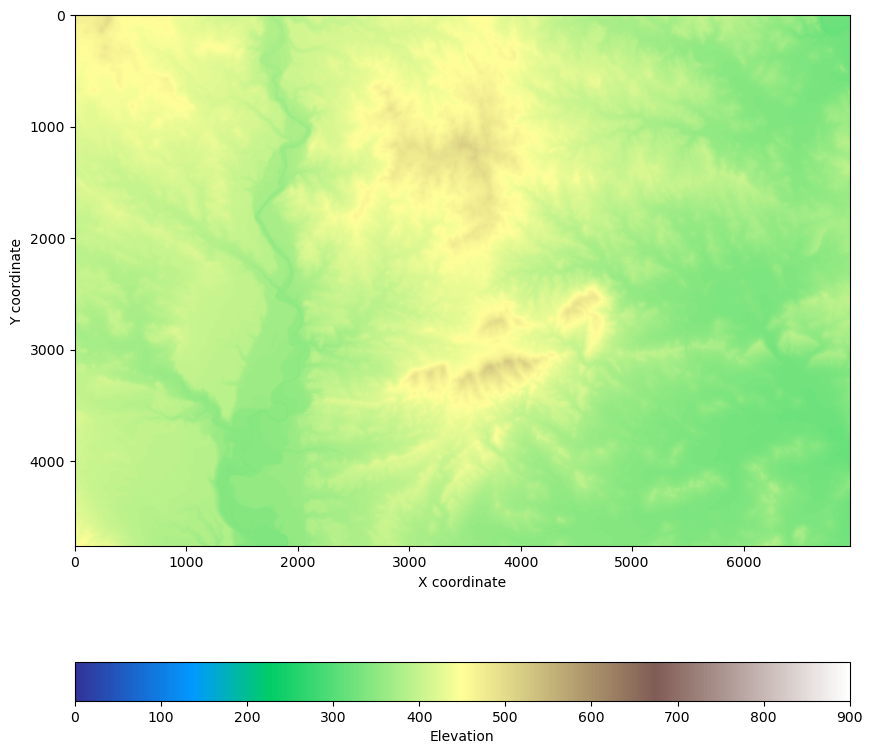

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

# Use vmin y vmax to set the color range
im = ax.imshow(raster_data, cmap='terrain', vmin=0, vmax=900)

# Pass the 'im' object directly to fig.colorbar().
fig.colorbar(im, ax=ax,orientation='horizontal', label='Elevation')


ax.set_xlabel('X coordinate')
ax.set_ylabel('Y coordinate')
plt.show()

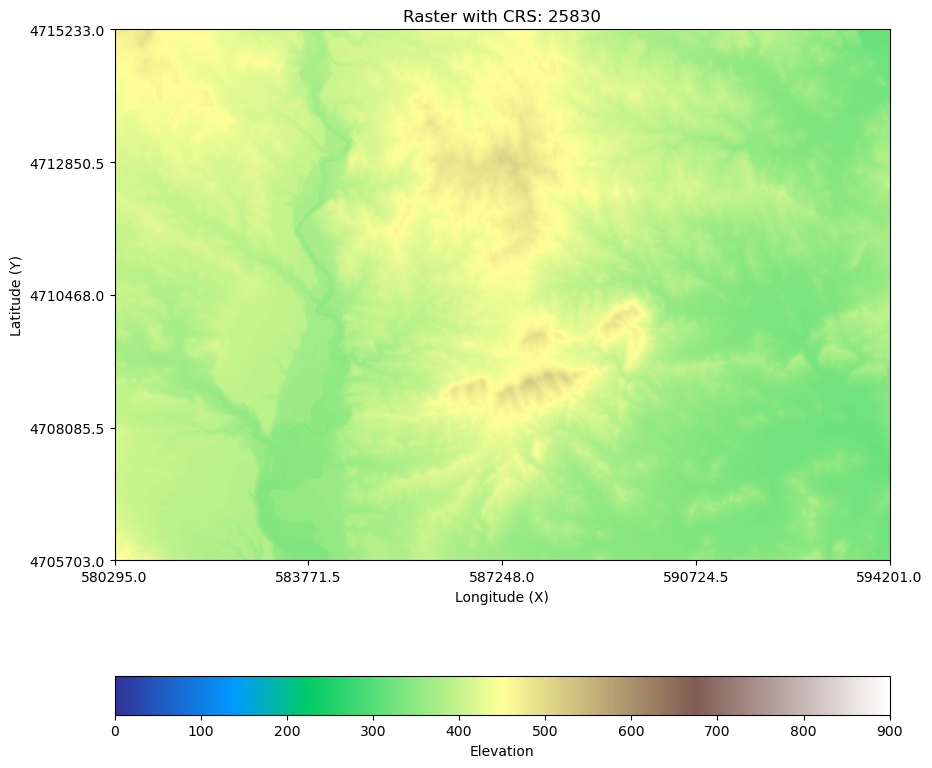

In [11]:
crs = src.crs
bounds = src.bounds
# Define the Matplotlib 'extent': [Xmin, Xmax, Ymin, Ymax]
# The coordinates for 'bounds' are already in this order (left, bottom, right, top)
plot_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Configure Ticks for Latitude/Longitude
# We generate equidistant points for the axis labels
num_ticks = 5
lon_ticks = np.linspace(bounds.left, bounds.right, num_ticks)
lat_ticks = np.linspace(bounds.bottom, bounds.top, num_ticks)

fig, ax = plt.subplots(figsize=(10, 10))

# We use the 'extent' parameter with the geographical boundaries
im = ax.imshow(
    raster_data, 
    cmap='terrain', 
    vmin=0, 
    vmax=900,
    extent=plot_extent  
)

# Add colorbar
fig.colorbar(im, ax=ax, orientation='horizontal', label='Elevation')

# Assign coordinate points as ticks
ax.set_xticks(lon_ticks)
ax.set_yticks(lat_ticks)

# Format labels
ax.set_xticklabels([f'{l:.1f}' for l in lon_ticks])
ax.set_yticklabels([f'{l:.1f}' for l in lat_ticks])

# Label the axes correctly
ax.set_xlabel('Longitude (X)')
ax.set_ylabel('Latitude (Y)')
ax.set_title(f'Raster with CRS: {crs.to_epsg() or crs.to_wkt()}')

plt.show()

In [12]:
# open each file with rasterio
src_files_to_mosaic = []
for file in raster_files:
    src = rasterio.open(file)
    src_files_to_mosaic.append(src)

# Join files into a mosaic. 
mosaic, out_transform = merge(src_files_to_mosaic)


In [13]:
mosaic

array([[[-32767., -32767., -32767., ..., -32767., -32767., -32767.],
        [-32767., -32767., -32767., ..., -32767., -32767., -32767.],
        [-32767., -32767., -32767., ..., -32767., -32767., -32767.],
        ...,
        [-32767., -32767., -32767., ..., -32767., -32767., -32767.],
        [-32767., -32767., -32767., ..., -32767., -32767., -32767.],
        [-32767., -32767., -32767., ..., -32767., -32767., -32767.]]],
      dtype=float32)

In [14]:
# Contains the georeferencing information for your new raster, including its pixel size, rotation, and upper-left corner coordinates.
out_transform

Affine(2.0, 0.0, 580295.0,
       0.0, -2.0, 4715433.0)

In [15]:
# Gets the metadata from an original file for the new mosaic
out_meta = src.meta.copy()

# Update mosaic metadata
out_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform,
})

# Save the mosaic to a new file
output_dir='Data/Results/'
output_path = os.path.join(output_dir, 'final_mosaic.tif')
# Create a raster. It is necessary the write mode ("w")
with rasterio.open(output_path, "w", **out_meta) as dest:
    #Save the mosaic
    dest.write(mosaic)

# It is a good practice to close the file
for src in src_files_to_mosaic:
    src.close()

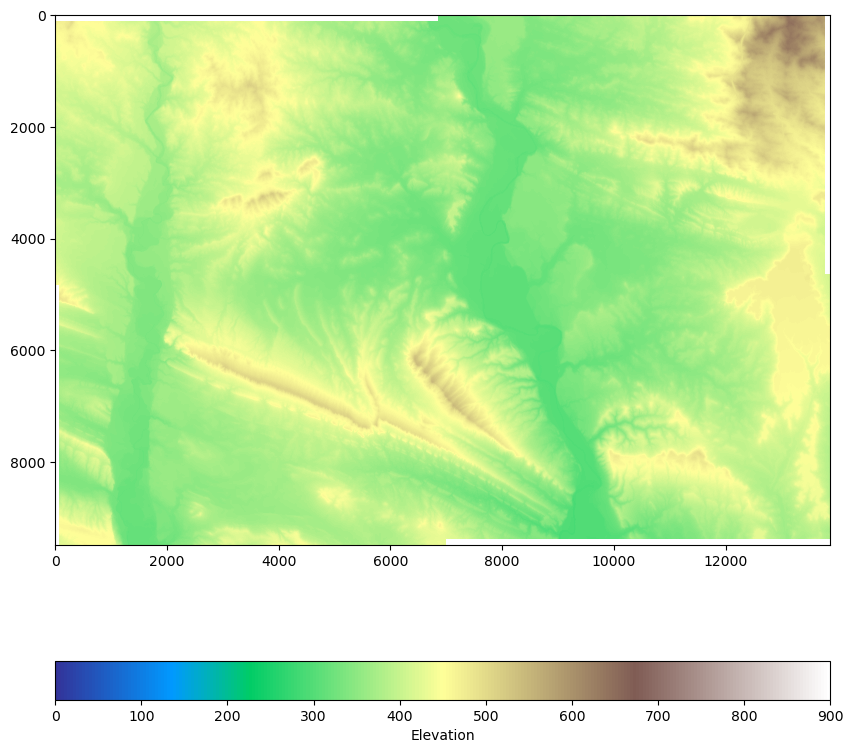

In [16]:
# Open the mosaic file and visualise it
raster_path = 'Data/Results/final_mosaic.tif'

with rasterio.open(raster_path) as src:
    raster_data = src.read(1)
    # Get the NoData value from the raster metadata
    nodata_value = src.nodata
    
    # Replaces pixels with the value of NoData with NaN
    if nodata_value is not None:
        raster_data[raster_data == nodata_value] = np.nan
        
    fig, ax = plt.subplots(figsize=(10, 10))

    im = ax.imshow(raster_data, cmap='terrain', vmin=0, vmax=900)

    fig.colorbar(im, ax=ax,orientation='horizontal', label='Elevation')

    plt.show()

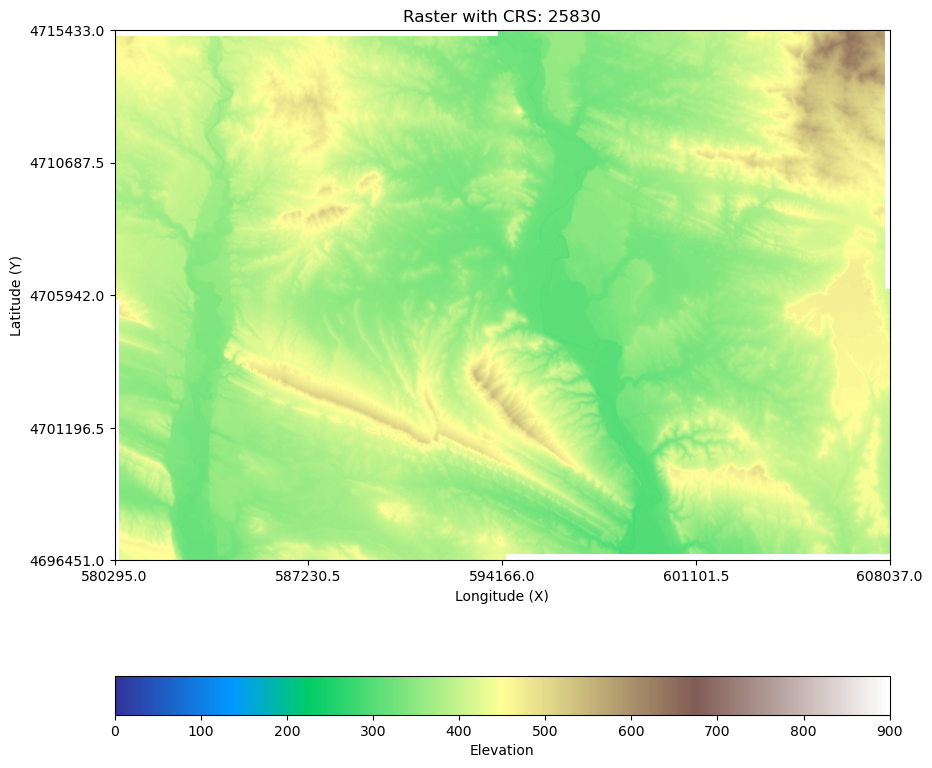

In [17]:
crs = src.crs
bounds = src.bounds
# Define the Matplotlib 'extent': [Xmin, Xmax, Ymin, Ymax]
# The coordinates for 'bounds' are already in this order (left, bottom, right, top)
plot_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Configure Ticks for Latitude/Longitude
# We generate equidistant points for the axis labels
num_ticks = 5
lon_ticks = np.linspace(bounds.left, bounds.right, num_ticks)
lat_ticks = np.linspace(bounds.bottom, bounds.top, num_ticks)



fig, ax = plt.subplots(figsize=(10, 10))

# We use the 'extent' parameter with the geographical boundaries
im = ax.imshow(
    raster_data, 
    cmap='terrain', 
    vmin=0, 
    vmax=900,
    extent=plot_extent  
)

# Add colorbar
fig.colorbar(im, ax=ax, orientation='horizontal', label='Elevation')

# Assign coordinate points as ticks
ax.set_xticks(lon_ticks)
ax.set_yticks(lat_ticks)

# Format labels
ax.set_xticklabels([f'{l:.1f}' for l in lon_ticks])
ax.set_yticklabels([f'{l:.1f}' for l in lat_ticks])

# Label the axes correctly
ax.set_xlabel('Longitude (X)')
ax.set_ylabel('Latitude (Y)')
ax.set_title(f'Raster with CRS: {crs.to_epsg() or crs.to_wkt()}')

plt.show()

## Resampling

<span style="font-size:120%">

_**Raster resampling**_ is the process of changing a raster's spatial resolution, either by increasing or decreasing the size of its pixels. During this process, a new value is calculated for each new pixel based on the values of the original pixels. _Upsampling_ is the process of converting a raster to a higher resolution, which means creating smaller grid cells. This is typically done to increase the level of detail in the data. Conversely, _downsampling_ is when you convert a raster to a lower resolution, resulting in larger grid cells. This technique is often used to reduce file size and speed up processing.</br>
Three common methods are used for resampling: nearest neighbour, bilinear interpolation, and cubic convolution.

__Nearest Neighbour:__
This is the simplest and fastest method. The new pixel's value is taken directly from the nearest pixel in the original raster. Because it does not create new values, this method is ideal for categorical data, such as land-use classifications, where you want to maintain the integrity of discrete classes.

__Bilinear Interpolation:__
This method calculates a new pixel's value using a weighted average of the four closest pixels from the original raster. It creates new, interpolated values in the output, resulting in a smoother appearance than nearest neighbour. It is best used for continuous data, such as elevation, temperature, or precipitation.

__Cubic Convolution:__
The most computationally intensive method, cubic convolution calculates a new pixel's value using a weighted average of the 16 closest pixels from the original raster. This produces the smoothest result but can create values outside the original data range. Like bilinear interpolation, it is best suited for continuous data.
</br>
</br>
Information: https://rasterio.readthedocs.io/en/stable/topics/resampling.html
</span>

In [18]:
# Define the input and output path
input_raster_path = 'Data//Results//final_mosaic.tif'
output_raster_path = 'Data//Results//mosaic_resampled.tif'

# Define the scale factor
scale_factor = 2

# Open the mosaic
with rasterio.open(input_raster_path) as src:
    # Get NoData from original metadata
    nodata_value = src.nodata

    # Calculates the new width and height of the raster
    new_width = src.width // scale_factor
    new_height = src.height // scale_factor

    # Read the band and specify the value of Nodata
    new_raster_data = src.read(
        out_shape=(src.count, new_height, new_width),
        resampling=Resampling.bilinear,
        fill_value=nodata_value
    )

    # Update raster metadata
    out_meta = src.meta.copy()
    out_meta.update({
        "height": new_height,
        "width": new_width,
        "transform": src.transform * src.transform.scale(
            (src.width / new_width),
            (src.height / new_height)
        ),
        "nodata": nodata_value })

    # Save the resampled raster
    with rasterio.open(output_raster_path, "w", **out_meta) as dest:
        dest.write(new_raster_data)


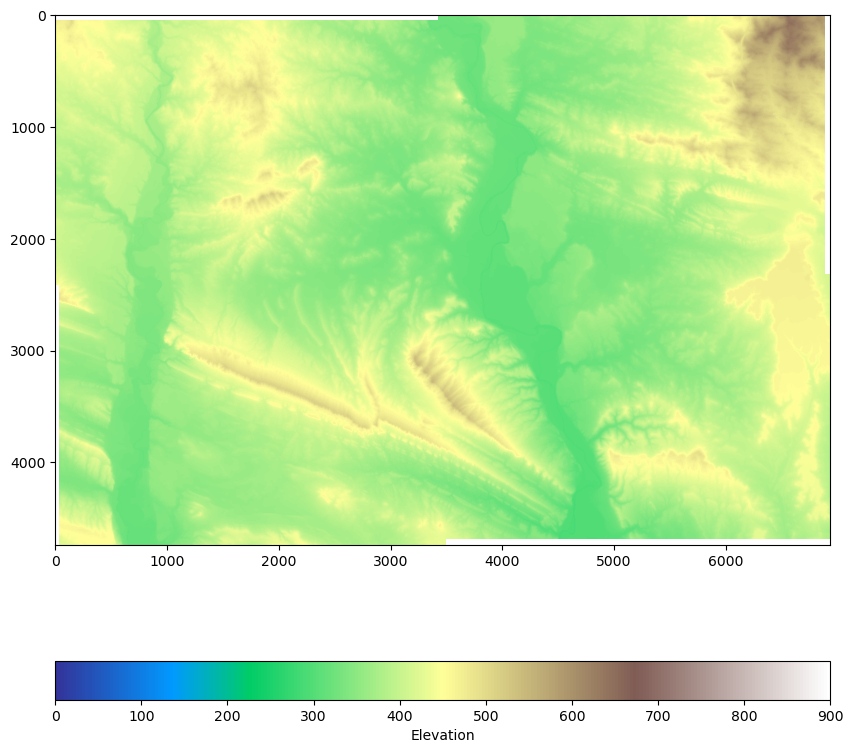

In [19]:
# Plot the resampled mosaic
raster_path = 'Data//Results//mosaic_resampled.tif'

with rasterio.open(raster_path) as src:
    raster_data = src.read(1)
    # Get the NoData value from the raster metadata
    nodata_value = src.nodata
    
    # Replaces pixels with the value of NoData with NaN
    if nodata_value is not None:
        raster_data[raster_data == nodata_value] = np.nan

    fig, ax = plt.subplots(figsize=(10, 10))

    im = ax.imshow(raster_data, cmap='terrain', vmin=0, vmax=900)

    fig.colorbar(im, ax=ax,orientation='horizontal', label='Elevation')

    plt.show()

## Raster mask

<span style="font-size:120%">
To avoid calculating the slope for the entire area, we will clip our raster based on the agricultural plots from the previous exercise. Therefore, we will need to load the vector files first.
</span>

In [25]:
direc='Data\\Plots_Clas1\\Plots_Clas1.csv'

In [21]:
# We load our agricultural plots
plots=pd.read_csv(direc)

In [22]:
# Convert the string column to actual Shapely geometry objects
# This uses the loads() function from the wkt (Well-Known Text) module
plots['geometry'] = plots['geometry'].apply(wkt.loads)

# Create the GeoDataFrame
# Now the 'geometry' column contains valid Shapely objects, so GeoPandas can process it correctly.
plots = gpd.GeoDataFrame(plots, geometry='geometry', crs='EPSG:25830')


<AxesSubplot:>

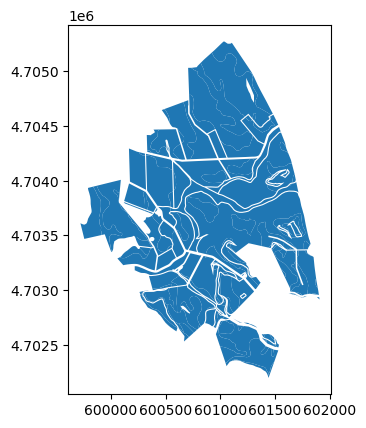

In [23]:
plots.plot()

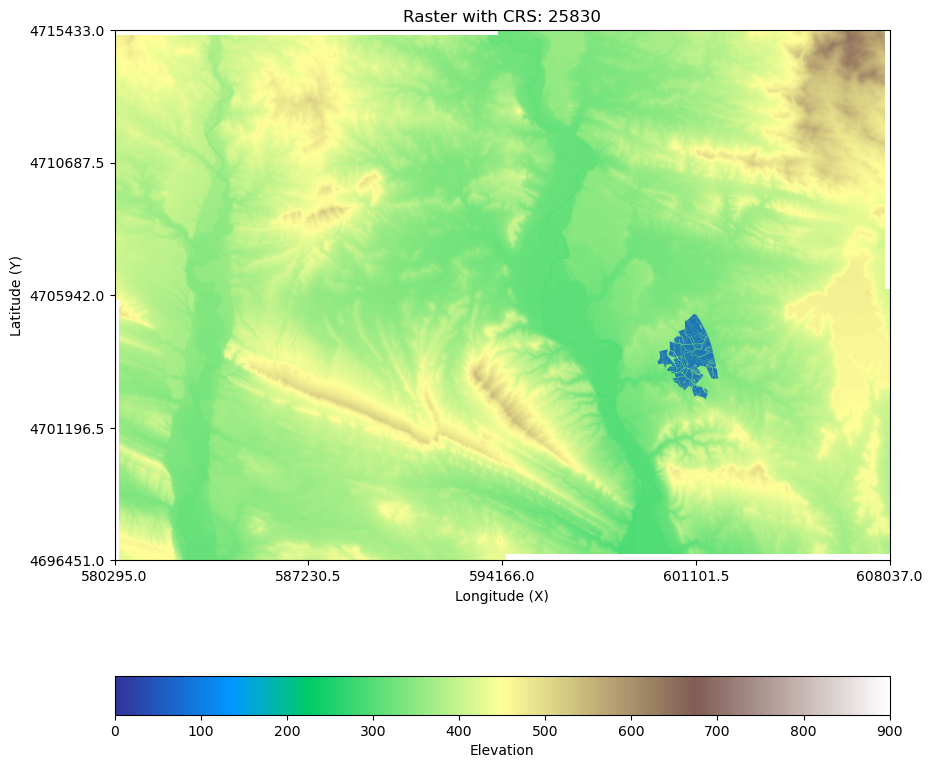

In [26]:
crs = src.crs
bounds = src.bounds
# Define the Matplotlib 'extent': [Xmin, Xmax, Ymin, Ymax]
# The coordinates for 'bounds' are already in this order (left, bottom, right, top)
plot_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Configure Ticks for Latitude/Longitude
# We generate equidistant points for the axis labels
num_ticks = 5
lon_ticks = np.linspace(bounds.left, bounds.right, num_ticks)
lat_ticks = np.linspace(bounds.bottom, bounds.top, num_ticks)



fig, ax = plt.subplots(figsize=(10, 10))

# We use the 'extent' parameter with the geographical boundaries
im = ax.imshow(
    raster_data, 
    cmap='terrain', 
    vmin=0, 
    vmax=900,
    extent=plot_extent  
)

# Add colorbar
fig.colorbar(im, ax=ax, orientation='horizontal', label='Elevation')

# Add agricultural plots
plots.plot(ax=ax)

# Assign coordinate points as ticks
ax.set_xticks(lon_ticks)
ax.set_yticks(lat_ticks)

# Format labels
ax.set_xticklabels([f'{l:.1f}' for l in lon_ticks])
ax.set_yticklabels([f'{l:.1f}' for l in lat_ticks])

# Label the axes correctly
ax.set_xlabel('Longitude (X)')
ax.set_ylabel('Latitude (Y)')
ax.set_title(f'Raster with CRS: {crs.to_epsg() or crs.to_wkt()}')

plt.show()

<span style="font-size:120%">
With the agricultural plots loaded, it is possible to apply a mask to the resampled raster using rasterio to retain only the area of interest. There are two options for generating a mask; the most appropriate method depends on our final objective. On the one hand, we can clip the raster taking into account the full extension of the vector layer (the clip will be rectangular), or we can clip our raster considering the geometry of our plots. In this latter crop, all pixels outside the area of our plots will have no value (no data).

</span>

- First option

In [27]:
# Mosaic resampled path
raster_path = 'Data/Results/mosaic_resampled.tif'

# 1. Get the boundaries of the vector layer
bounds = plots.total_bounds
minx, miny, maxx, maxy = bounds

# 2. Open the raster and define the clipping window
with rasterio.open(raster_path) as src:
    # Creates a clipping window from the polygon boundaries
    window = from_bounds(minx, miny, maxx, maxy, src.transform)
    # Reads raster data into the clipping window
    out_image = src.read(window=window)
    # Update and save the metadata of the new raster
    out_meta = src.meta.copy()
    out_meta.update({
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": src.window_transform(window)
    })
    # Save the clipped file
    output_path = 'Data/Results/DEM_clip.tif'
    with rasterio.open(output_path, "w", **out_meta) as dest:
        dest.write(out_image)



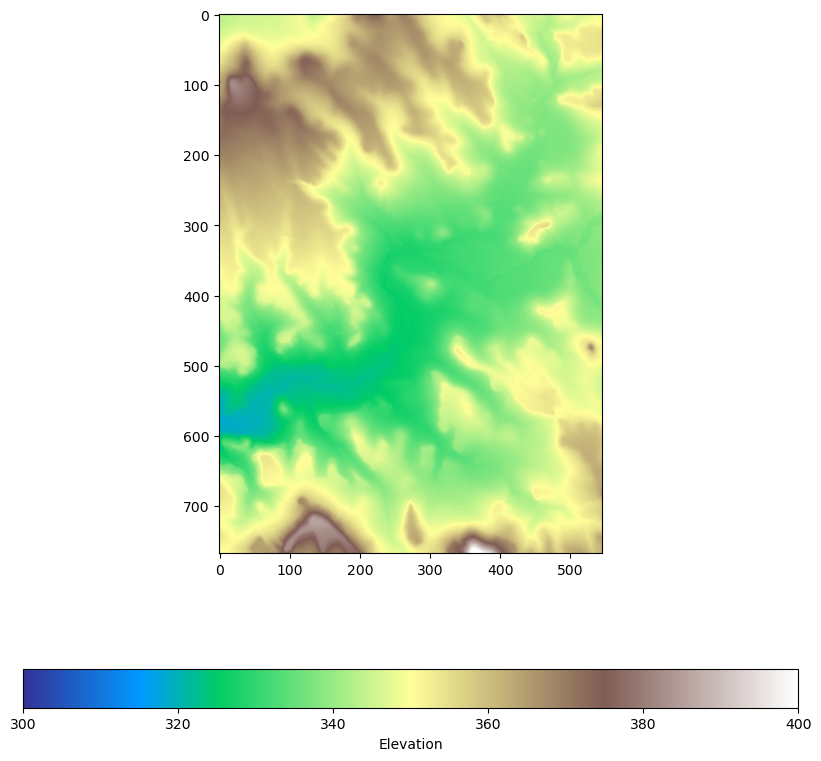

In [28]:
# Plot clipped raster
raster_path = 'Data/Results/DEM_clip.tif'

with rasterio.open(raster_path) as src:
    raster_data = src.read(1)

    fig, ax = plt.subplots(figsize=(10, 10))

    # Usa vmin y vmax para establecer el rango de colores
    im = ax.imshow(raster_data, cmap='terrain', vmin=300, vmax=400)

    fig.colorbar(im, ax=ax,orientation='horizontal', label='Elevation')

    plt.show()

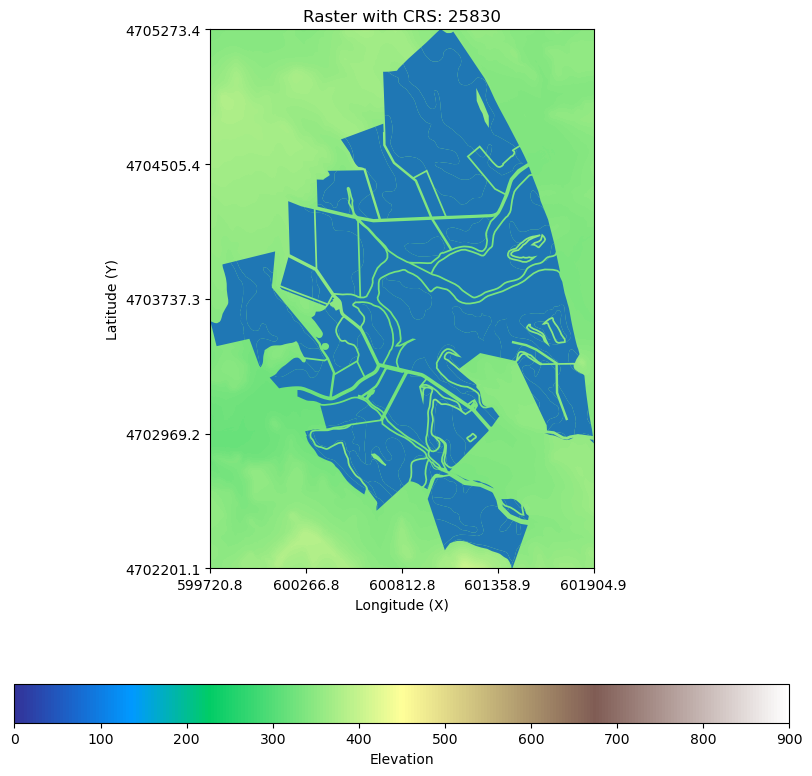

In [30]:
crs = src.crs
bounds = src.bounds
# Define the Matplotlib 'extent': [Xmin, Xmax, Ymin, Ymax]
# The coordinates for 'bounds' are already in this order (left, bottom, right, top)
plot_extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Configure Ticks for Latitude/Longitude
# We generate equidistant points for the axis labels
num_ticks = 5
lon_ticks = np.linspace(bounds.left, bounds.right, num_ticks)
lat_ticks = np.linspace(bounds.bottom, bounds.top, num_ticks)



fig, ax = plt.subplots(figsize=(10, 10))

# We use the 'extent' parameter with the geographical boundaries
im = ax.imshow(
    raster_data, 
    cmap='terrain', 
    vmin=0, 
    vmax=900,
    extent=plot_extent  
)

# Add colorbar
fig.colorbar(im, ax=ax, orientation='horizontal', label='Elevation')

plots.plot(ax=ax)

# Assign coordinate points as ticks
ax.set_xticks(lon_ticks)
ax.set_yticks(lat_ticks)

# Format labels
ax.set_xticklabels([f'{l:.1f}' for l in lon_ticks])
ax.set_yticklabels([f'{l:.1f}' for l in lat_ticks])

# Label the axes correctly
ax.set_xlabel('Longitude (X)')
ax.set_ylabel('Latitude (Y)')
ax.set_title(f'Raster with CRS: {crs.to_epsg() or crs.to_wkt()}')

plt.show()

- Second option

In [31]:
# Second option. Mask considering vector shape
with rasterio.open(raster_path) as src:
    single_geometry = plots.unary_union
    
    # mapping() converts the shapely geometry into a GeoJSON-like dictionary
    geometries = [mapping(single_geometry)]
    

    output_path = 'Data/Results/DEM_clip_geometries.tif'
    # Apply mask
    out_image, out_transform = rasterio.mask.mask(src, geometries, crop=True)
    
    # Update and save the metadata of the new raster
    out_meta = src.meta.copy()
    out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
    
    # Save the clipped file
    with rasterio.open(output_path, "w", **out_meta) as dest:
            dest.write(out_image)

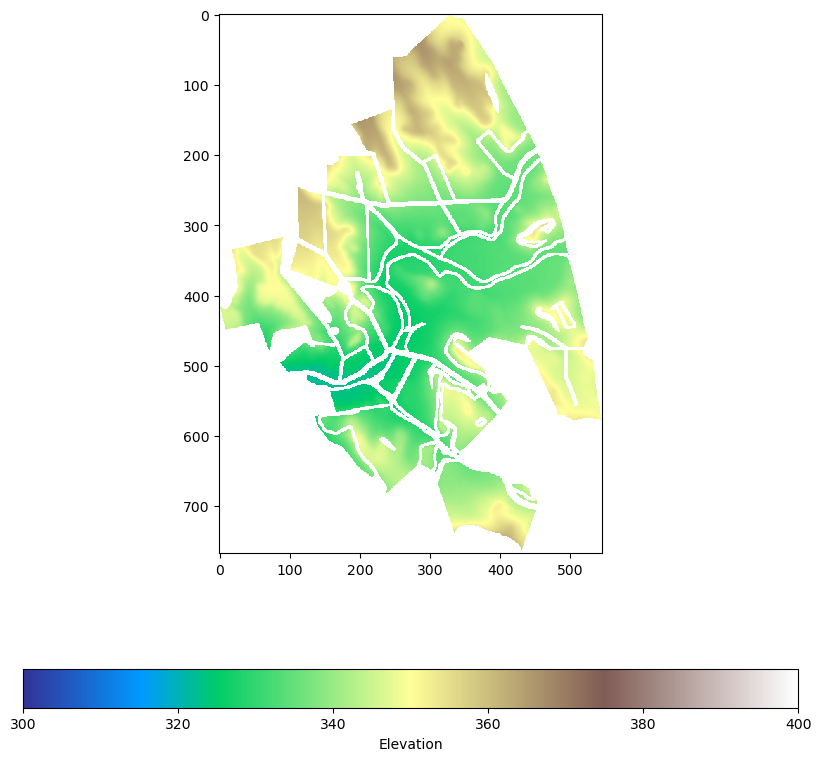

In [32]:
# Plot clipped raster
raster_path = 'Data/Results/DEM_clip_geometries.tif'

with rasterio.open(raster_path) as src:
    raster_data = src.read(1)
    # Get the NoData value from the raster metadata
    nodata_value = src.nodata
    
    # Replaces pixels with the value of NoData with NaN
    if nodata_value is not None:
        raster_data[raster_data == nodata_value] = np.nan
        

    fig, ax = plt.subplots(figsize=(10, 10))

    # Usa vmin y vmax para establecer el rango de colores
    im = ax.imshow(raster_data, cmap='terrain', vmin=300, vmax=400)

    fig.colorbar(im, ax=ax,orientation='horizontal', label='Elevation')

    plt.show()

## Slope calcultation

<span style="font-size:120%">
From a DEM (Digital Elevation Model), it's possible to derive multiple variables that are very useful in agricultural management. Some of these include slope, aspect, hillshade, contour lines, and various topographic indices.</br>
As discussed in this tutorial, Rasterio facilitates the manipulation of raster data in a user-friendly way. However, some advanced terrain analyses, such as calculating slope, are often implemented using the underlying GDAL library, as it provides a comprehensive set of functions for these tasks. In this section, we'll calculate slope using the gdal.DEMProcessing() method.</br>
For information on calculating other variables, you can refer to the following link.
</br></br>
    
Information: https://gdal.org/en/stable/api/python/utilities.html
</span>

In [33]:
# Clipped DEM path
input_raster_path = 'Data/Results/DEM_clip.tif'

# Path to save the slope
output_slope_path = 'Data/Results/Slope.tif'

# Call gdal.DEMProcessing function to calculate the slope
slope_raster = gdal.DEMProcessing(
    output_slope_path,
    input_raster_path,
    'slope',
    options=gdal.DEMProcessingOptions(computeEdges=True, slopeFormat ='percent')
)

# It is good practice to close the dataset to free up memory.
slope_raster = None

In [34]:
# Load slope raster and get maximum and minimum values
raster_path = 'Data/Results/Slope.tif'

with rasterio.open(raster_path) as src:
    raster_data = src.read(1)
    print('Maximum slope: ',raster_data.max())
    print('Minimum slope: ',raster_data.min())

Maximum slope:  73.91262
Minimum slope:  0.009724596


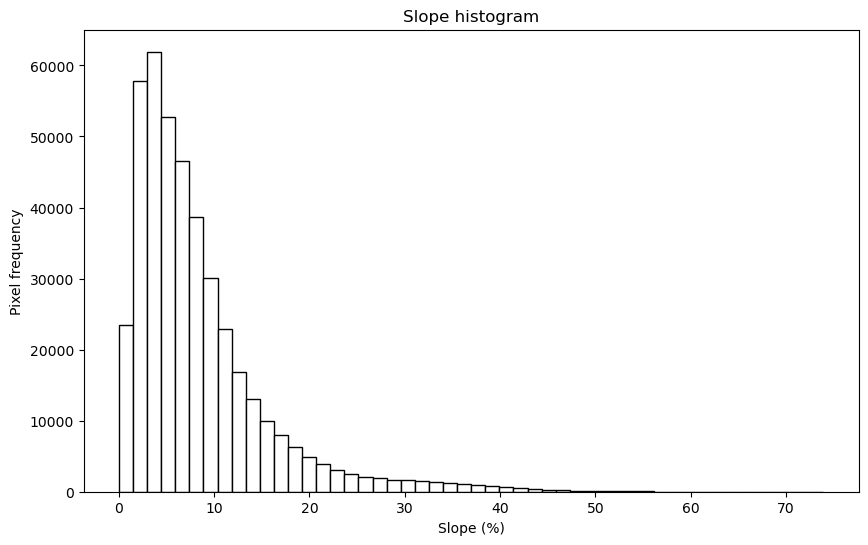

In [35]:
# Load slope raster and get maximum and minimum values
raster_path = 'Data/Results/Slope.tif'

with rasterio.open(raster_path) as src:
    raster_data = src.read(1)
    # Create the histogram
    # Flatten the array to a 1D array for the histogram
    flattened_data = raster_data.flatten()
    
    # Exclude NoData values if they exist
    if src.nodata is not None:
        valid_data = flattened_data[flattened_data != src.nodata]
    else:
        valid_data = flattened_data
    
    # Plot the histogram
    plt.figure(figsize=(10, 6))
    plt.hist(valid_data, bins=50, color='white', edgecolor='black')
    
    plt.title('Slope histogram')
    plt.xlabel('Slope (%)')
    plt.ylabel('Pixel frequency')
    plt.grid(False)
    plt.show()

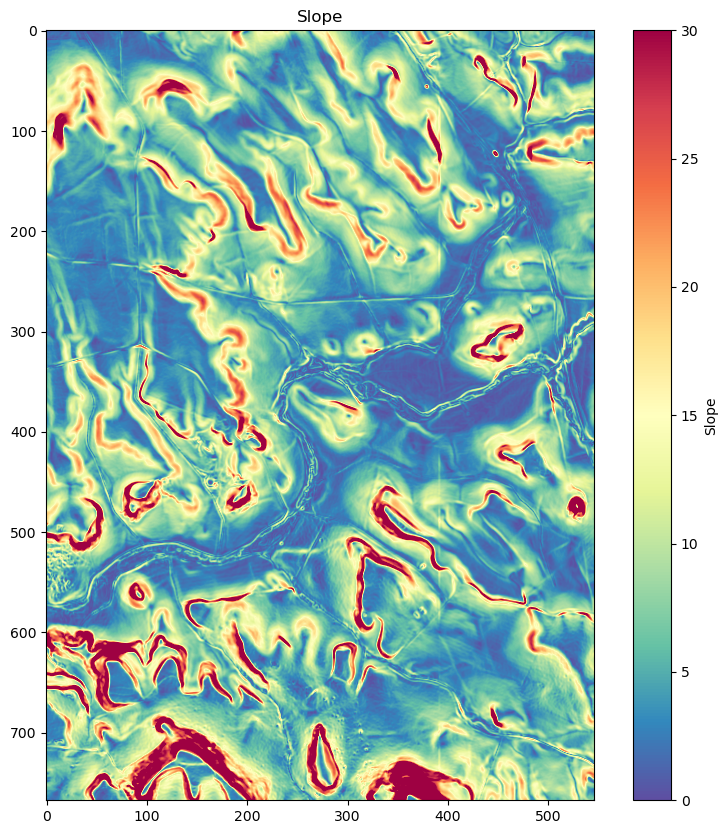

In [36]:
# Plot the slope
raster_path = 'Data/Results/Slope.tif'

with rasterio.open(raster_path) as src:
    raster_data = src.read(1)

    fig, ax = plt.subplots(figsize=(10, 10))

    
    im = ax.imshow(raster_data, cmap='Spectral_r', vmin=0, vmax=30)

    fig.colorbar(im, ax=ax, label='Slope')

    ax.set_title('Slope')

    plt.show()

## Zonal statistics

<span style="font-size:120%">
We have calculated the slope in the study area, but what's the average slope of our plot? What's the maximum and minimum? Knowing the intrinsic characteristics of our plots, provided by raster data, is essential for decision-making.
In order to do these calculations, it is necessary to use the rasterstats library.
</span>

In [37]:
# Slope path
pendiente_raster_path = 'Data/Results/Slope.tif'

# Zonal statistics
stats = zonal_stats(
    plots,
    pendiente_raster_path,
    stats=['mean', 'max', 'min'],
    geojson_out=False
)
stats

[{'min': 1.9177039861679077,
  'max': 23.706998825073242,
  'mean': 8.424654853170479},
 {'min': 0.30036306381225586,
  'max': 19.23802375793457,
  'mean': 8.411516621674771},
 {'min': 0.15741823613643646,
  'max': 23.92388916015625,
  'mean': 9.67990619757811},
 {'min': 0.11178311705589294,
  'max': 12.82187557220459,
  'mean': 5.1775224223584},
 {'min': 6.474188327789307,
  'max': 22.401554107666016,
  'mean': 14.346277794471154},
 {'min': 5.87908935546875,
  'max': 20.106786727905273,
  'mean': 9.960185534466328},
 {'min': 0.20676568150520325,
  'max': 12.555817604064941,
  'mean': 3.769214264523056},
 {'min': 0.8492717742919922,
  'max': 16.84235191345215,
  'mean': 6.172180641698473},
 {'min': 0.8553228378295898,
  'max': 20.429004669189453,
  'mean': 11.77856599636536},
 {'min': 0.16830076277256012,
  'max': 27.277158737182617,
  'mean': 8.885590914857902},
 {'min': 0.5465887784957886,
  'max': 56.000911712646484,
  'mean': 18.23368248375943},
 {'min': 2.164198637008667,
  'max':

In [39]:
type(stats[0])

dict

In [41]:
stats[0].keys()

dict_keys(['min', 'max', 'mean'])

In [42]:
# Extract zonal statistics and add them into the GeoDataFrame
mean_slope = [d['mean'] for d in stats]
max_slope = [d['max'] for d in stats]
min_slope = [d['min'] for d in stats]

plots['Mean_slope'] = mean_slope
plots['Max_slope'] = max_slope
plots['Min_slope'] = min_slope

# See the first rows
print(plots[['IDPLOT', 'Mean_slope','Max_slope','Min_slope']].head())

#  Save the updated GeoDataFrame
output_gdf_path = 'Data/Results/Plots_with_slope.shp'
plots.to_file(output_gdf_path)

      IDPLOT  Mean_slope  Max_slope  Min_slope
0  1308.01.0    8.424655  23.706999   1.917704
1  1308.01.0    8.411517  19.238024   0.300363
2  1308.01.0    9.679906  23.923889   0.157418
3  1309.01.0    5.177522  12.821876   0.111783
4  1309.01.0   14.346278  22.401554   6.474188


## Raster reclassification

<span style="font-size:120%">
In agriculture, it is sometimes necessary to simplify information by adding data that provide similar information. Raster reclassification is a fundamental tool for simplifying and making sense of complex data. It converts a set of pixel values into a new set of values, creating categories that are easier to interpret and analyze. A simple tool, for example, is if we want to perform crop management zoning: If you have a slope raster with continuous values from 0 to 100 percent, you can reclassify it into categories. For example:
</br>
0-2% = "Flat slope"
</br>
2-6% = "Slightly steep slope"
</br>
6-13% = "Moderately steep slope"
</br>
13-25% = "Steep slope"
</br>
This allows you to quickly identify areas where different soil management is needed to prevent erosion. </br>
In Python, to perform these reclassifications, it is necessary to create masks that group the pixels belonging to each slope range (in this case) and assign them a new categorical label that allows us to identify the class to which each pixel corresponds.
</span>

In [43]:
# Paths
input_raster_path = 'Data/Results/Slope.tif'
output_reclass_path = 'Data/Results/Reclass_Slope.tif'

# Read the raster
with rasterio.open(input_raster_path) as src:
    slope_data = src.read(1)
    profile = src.profile # Save the metadata for the outcome raster
    nodata_value = src.nodata

# Defines the reclassification ranges
# The values will be assigned as follows:
# 1 for slopes from 0% to 5%
# 2 for slopes from 5% to 15%
# 3 for slopes greater than 15%
reclass_ranges = [
    (0, 2, 1),
    (2, 6, 2),
    (6, 13, 3),
    (13, np.inf, 4) # np.inf represents infinity for the last range
]

# Creates an empty array for the results and handles NoData values
reclass_data = np.full(slope_data.shape, nodata_value, dtype=profile['dtype'])

# Apply reclassification logic using a loop and NumPy masks
for min_val, max_val, new_val in reclass_ranges:
    # Creates a boolean mask for the pixels within the range
    mask = (slope_data >= min_val) & (slope_data < max_val)
    
    # Assign the new value to those pixels
    reclass_data[mask] = new_val

# Save the new reclassified raster
# Update metadata if necessary 
profile.update(dtype=rasterio.float32)

with rasterio.open(output_reclass_path, 'w', **profile) as dest:
    dest.write(reclass_data.astype(profile['dtype']), 1)

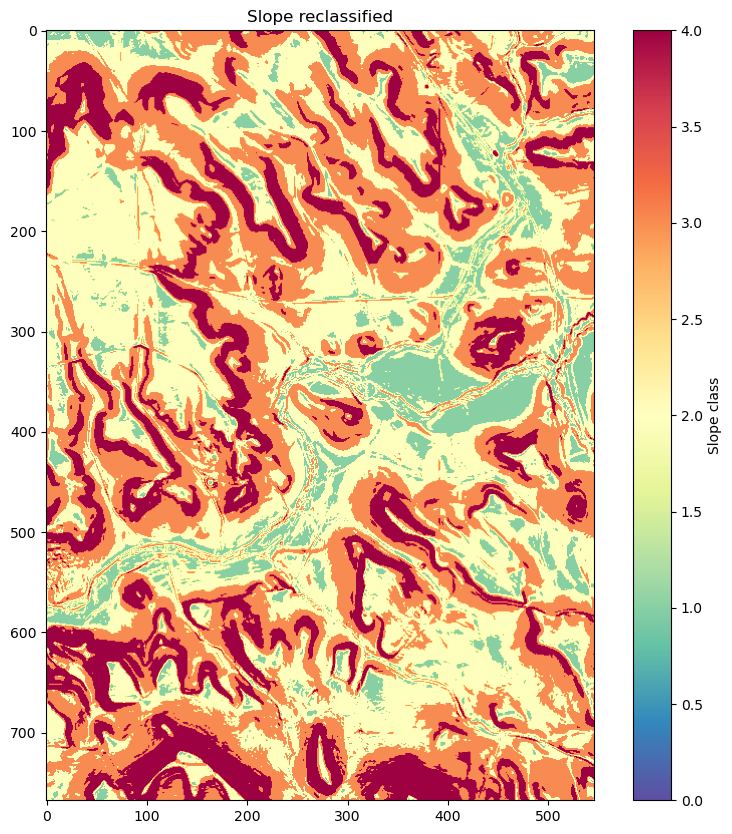

In [44]:
# Define the path to your output raster file
raster_path = 'Data/Results/Reclass_Slope.tif'

with rasterio.open(raster_path) as src:
    raster_data = src.read(1)

    fig, ax = plt.subplots(figsize=(10, 10))

    # Use vmin and vmax to set the color range
    im = ax.imshow(raster_data, cmap='Spectral_r', vmin=0, vmax=4)

    fig.colorbar(im, ax=ax, label='Slope class')

    ax.set_title('Slope reclassified')
    plt.show()

## Web services

<span style="font-size:120%">
Web services are standard protocols defined by the Open Geospatial Consortium (OGC) that allow users to access geospatial data over the internet. These services are the foundation of interoperability in geographic information systems (GIS), as they allow different applications (such as QGIS, ArcGIS, or a web browser) to share map data regardless of their format or underlying software.</br>
One of the great advantages of web services is that the information isn't stored on our computer, so they allow us to access a large number of layers without taking up memory.</br>
Hay tres grandes tipos de servicios web:</br>

•	**WMS (Web Map Service)**: The Web Map Service is a service for accessing geo-referenced maps in the form of images.</br>
•	**WFS (Web Feature Service)**: The Web Feature Service is a service for accessing vector data (points, lines, and polygons). Unlike WMS, WFS does not send an image, but rather the geometries and attributes of the data.</br>
•	**WCS (Web Coverage Service)**: The Web Coverage Service is a service for accessing raster or "coverage" data, such as satellite images, digital elevation models (DEMs), or temperature data. The main difference with WMS is that WCS sends the data in its original format, not as an image.</br>
In this activity we will use an orthophoto provided by the IDENA WMS web service as a base map.
</span>

In [45]:
# Define the URL of the WMS service and the layer you want
wms_url = 'https://idena.navarra.es/ogc/wms'
layer_name = 'ortofoto_maxima_actualidad'
crs = 'EPSG:25830'  

# Define a polygon of interest (bounding box) at the correct coordinates
bbox = plots.total_bounds # our plots' bounding box (minx, miny, maxx, maxy)

# Connect to the WMS service
wms = WebMapService(wms_url)

# Request the image from the server
# Use the layer parameters, the bounding box, and the image format
img = wms.getmap(
    layers=[layer_name],
    srs=crs,
    bbox=bbox,
    size=(500, 500), # Tamaño de la imagen en píxeles
    format='image/jpeg'
)

# Save the image to a temporary file
with open('ortofoto_temp.jpg', 'wb') as fp:
    fp.write(img.read())

# Read the file with raster and plot it
with rasterio.open('ortofoto_temp.jpg') as src:
    fig, ax = plt.subplots(figsize=(10, 10))
    show(src, ax=ax)
    ax.set_title('Ortophoto (WMS)')
    plt.show()

SSLError: HTTPSConnectionPool(host='idena.navarra.es', port=443): Max retries exceeded with url: /ogc/wms?service=WMS&request=GetCapabilities&version=1.1.1 (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1091)')))

## Visualizacion

In [50]:
# Data loading and preparation
color_map = {
    'Typic Calcixerept': '#FFC0CB', 
    'Pachic Calcixeroll': '#87CEEB',   
    'Lithic Haploxeroll': '#A52A2A',   
    'Lithic Xeric Torriorthent': '#FFD700',  
    'Fluventic Haploxerept':'#3a5a40',
    'Xeric Torriorthent': '#800080',   
    'Paralithic Xeric Torriorthent': '#D3D3D3'    
}
# Modify the style_function to use the colormap
# The 'x' function represents each feature in the GeoJSON
def style_functions(feature):
    soil_type = feature['properties']['SOILTAXON1']
    color = color_map.get(soil_type, '#808080') 
    return {
        'fillColor': color,
        'color': 'black',  
        'weight': 1,
        'fillOpacity': 0.7
    }

# Load plots
parcelas = plots
parcelas = parcelas.to_crs('EPSG:4326')

# Load reclassified raster
raster_path = 'Data/Results/Reclass_Slope.tif'
with rasterio.open(raster_path, 'r+') as src:
    # Assign the correct CRS to the raster metadata
    src.crs = 'EPSG:25830'
    raster_data = src.read(1)
    # Transform the raster boundaries to EPSG:4326
    # This is crucial for overlaying in Folium
    bounds_epsg_25830 = src.bounds
    minx, miny, maxx, maxy = transform_bounds(src.crs, 'EPSG:4326', *bounds_epsg_25830)
    bounds_latlon = [[miny, minx], [maxy, maxx]]
    # Displays the raster and converts it to an image for Folium
    # It is necessary to save the raster as a georeferenced image for Folium to read it
    # We will do this in memory for simplicity
    cmap = plt.colormaps['viridis']
    norm = Normalize(vmin=0, vmax=4)
    raster_colored = cmap(norm(raster_data))

# Creating the basemap
# Folium will automatically adjust the center when using fit_bounds
m = folium.Map()

# Add layers
# Orthophoto layer (IDENA WMS)
folium.raster_layers.WmsTileLayer(
    url='https://idena.navarra.es/ogc/wms',
    name='Ortophoto',
    layers='ortofoto_maxima_actualidad',
    attr='IDENA - Gobierno de Navarra',
    overlay=True,
    control=True
).add_to(m)

# Classified Raster Layer
# Use ImageOverlay to overlay the raster image over the basemap
folium.raster_layers.ImageOverlay(
    image=raster_colored, 
    bounds=bounds_latlon, 
    opacity=0.6,
    name='Slope reclassified'
).add_to(m)


# Add the parcels layer with the new style_function
folium.GeoJson(
    parcelas.to_json(),
    name='Agricultural plots',
    tooltip=folium.features.GeoJsonTooltip(fields=['SOILTAXON1']),
    style_function=style_functions
).add_to(m)

# Add layer control and zoom
folium.LayerControl().add_to(m)
# Add Legend for Soil Types

# Create the HTML legend
legend_html = '''
     <div style="position: fixed; 
                 bottom: 50px; left: 50px; width: 180px; height: auto; 
                 border:2px solid grey; z-index:9999; font-size:14px;
                 background-color:white; opacity:0.9;">
       <div style="padding: 10px;">
         <p style="margin-bottom:5px; font-weight: bold;">Type of soil</p>
         <ul style="list-style: none; padding: 0;">
'''

# Add legend entries dynamically
for soil_type, color in color_map.items():
    legend_html += f'''
          <li style="margin-bottom: 5px;">
            <i style="background: {color}; width: 18px; height: 18px; display: inline-block; border: 1px solid black; vertical-align: middle;"></i>
            <span style="margin-left: 5px; vertical-align: middle;">{soil_type}</span>
          </li>
    '''

legend_html += '''
         </ul>
       </div>
     </div>
'''

# Add the legend to the map as an HTML object
m.get_root().html.add_child(folium.Element(legend_html))
# Adjust zoom to the extent of the plots (now in lat/lon)
bounds = parcelas.total_bounds
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])

# Save the interactive map as an HTML file
m.save('corrected_interactive_map.html')